## Setup / Imports

### 1. Imports and environment sanity check

In this cell, we import the core `multimodal_mazes` library and basic utilities, and print out the current working directory (CWD) and the path from which the package is loaded.

This serves two purposes:
- It confirms that the notebook is being run from the `scripts/` folder, which is required because the library uses relative paths for plotting styles.
- It confirms that Python is using the editable installation of `multimodal_mazes` from this repository, rather than a cached or incorrect version.

This step helps catch environment and path issues early, before running any experiments.


In [95]:
import os
import numpy as np
import multimodal_mazes

print("CWD:", os.getcwd())
print("multimodal_mazes:", multimodal_mazes.__file__)


CWD: /Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/Multimodal_mazes/scripts
multimodal_mazes: /Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/Multimodal_mazes/multimodal_mazes/__init__.py


### 2. Generating a batch of mazes

Here we create a `GeneralMaze` task and generate a batch of independent mazes.

- `size=33` defines a 33×33 grid.
- `n_channels=2` specifies that each maze contains two sensory cue channels.
- `maze.generate(number=10)` samples 10 different mazes from the task distribution.

The resulting `maze` object stores:
- the maze layouts themselves (`maze.mazes`)
- the start locations (`maze.start_locations`)
- the goal locations (`maze.goal_locations`)
- the length of the shortest possible path for each maze (`maze.fastest_solutions`)

This defines the environment distribution that agents will be evaluated on.


In [96]:
maze = multimodal_mazes.GeneralMaze(size=33, n_channels=2)
maze.generate(number=10)

print("mazes:", len(maze.mazes))
print("start_locations:", len(maze.start_locations))
print("goal_locations:", len(maze.goal_locations))
print("fastest_solutions:", len(maze.fastest_solutions))
print("maze[0] shape:", maze.mazes[0].shape)


mazes: 10
start_locations: 10
goal_locations: 10
fastest_solutions: 10
maze[0] shape: (33, 33, 3)


### 3. Inspecting maze structure and sensory channels

Each maze is stored as a NumPy array of shape `(size, size, n_channels + 1)`.

In this cell, we separate:
- the **structural channel** (`mz[:, :, -1]`), which encodes walls (0.0) and free paths (1.0)
- the **sensory cue channels** (`mz[:, :, :-1]`), which provide gradient-like information guiding the agent toward the goal

Inspecting these components helps verify:
- the expected data shapes
- the range of values in the sensory cues
- our understanding of what information is available to the agent at each location


In [97]:
n = 0
mz = maze.mazes[n]

structure = mz[:, :, -1]
cues = mz[:, :, :-1]

print("structure unique values:", np.unique(structure))
print("cues shape:", cues.shape)  # (33, 33, 2)
print("cues min/max:", cues.min(), cues.max())


structure unique values: [0. 1.]
cues shape: (33, 33, 2)
cues min/max: 0.0 0.5


### 4. Creating a rule-based agent

Here we create a simple, non-learning agent using the `AgentRuleBased` class.

This agent:
- senses both sensory channels
- combines them using a linear fusion policy
- moves in the direction of the strongest combined signal

This agent serves as a baseline:
- it does not learn
- it has no internal memory or recurrence
- its behaviour is fully determined by the current sensory input

Using this simple agent allows us to validate the task setup before introducing neural or recurrent agents.


In [98]:
agnt = multimodal_mazes.AgentRuleBased(
    location=None,
    channels=[1, 1],
    policy="Linear fusion"
)

print("Agent:", type(agnt))


Agent: <class 'multimodal_mazes.agents.agent_rulebased.AgentRuleBased'>


### 5. Single maze trial and path visualisation

In this cell, we test the agent on a single maze instance.

The `maze_trial` function runs one episode in which the agent:
- starts at the maze's start location
- repeatedly senses its local environment
- selects an action based on its policy
- moves within the maze for up to `n_steps`

The function returns:
- the time taken (or failure indicator)
- the full trajectory of the agent's path

We then visualise the path overlaid on the maze, providing a qualitative check that the agent's behaviour is sensible and goal-directed.


time: 99
path length: 101


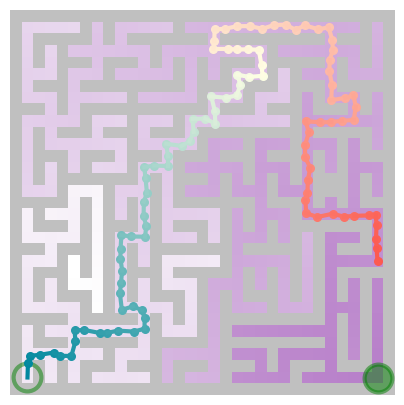

In [99]:
n = 0

time, path = multimodal_mazes.maze_trial(
    mz=maze.mazes[n],
    mz_start_loc=maze.start_locations[n],
    mz_goal_loc=maze.goal_locations[n],
    channels=[1,1],
    sensor_noise_scale=0.0,
    drop_connect_p=0.0,
    n_steps=100,
    agnt=agnt
)

print("time:", time)
print("path length:", len(path) if path is not None else None)

multimodal_mazes.plot_path(
    path,
    mz=maze.mazes[n],
    mz_goal_loc=maze.goal_locations[n],
    n_steps=100,
    style="gradients"
)


### 6. Batch evaluation and fitness computation

Here we evaluate the agent across the full batch of generated mazes.

The `eval_fitness` function:
- runs the agent on each maze in the batch
- compares the path taken to the maze's shortest possible path
- aggregates performance into a single fitness score between 0 and 1

A fitness value of:
- 1.0 indicates the agent always takes the optimal (shortest) path
- lower values indicate inefficiency or failure on some mazes

This quantitative score enables systematic comparison between different agents, architectures, and experimental conditions later in the project.


In [100]:
fitness = multimodal_mazes.eval_fitness(
    genome=None,
    config=None,
    channels=[1,1],
    sensor_noise_scale=0.0,
    drop_connect_p=0.0,
    maze=maze,
    n_steps=100,
    agnt=agnt
)

print("fitness:", fitness)


fitness: 0.8254169663729545


### 1. Experiment paths and setup

In this cell, we define the file system paths used in this experiment.

The trained agents are stored externally in the `pRNN_data` directory, organised into run folders such as `test1352`, each containing multiple pickled agents (e.g. `128.pickle`).

### Load feedforward (1.pickle) and fully recurrent (128.pickle) agents

We now load two agents from the same run:
- `1.pickle`: feedforward network  
- `128.pickle`: fully recurrent network  

These will be evaluated under the same perturbation protocol for a direct architectural comparison.

We explicitly define:
- the root results directory
- the specific run folder to analyse
- the agent ID to load

Using `pathlib.Path` makes the code robust to spaces in file paths and avoids fragile relative path assumptions.


In [101]:
from pathlib import Path
import pickle
import multimodal_mazes


RESULTS_DIR = Path("/Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/datasets/pRNN_data")
RUN_NAME = "test1352"
RUN_DIR = RESULTS_DIR / RUN_NAME

AGENT_CONFIGS = [
    {"agent_id": 1,   "arch": "FF"},
    {"agent_id": 128, "arch": "RNN_full"},
]

agents = {}

for cfg in AGENT_CONFIGS:
    aid = cfg["agent_id"]
    arch = cfg["arch"]
    p = RUN_DIR / f"{aid}.pickle"
    print(f"Loading agent {aid} ({arch}) from:", p)
    print("  Exists:", p.exists())
    with open(p, "rb") as f:
        a = pickle.load(f)
    agents[aid] = {"arch": arch, "obj": a}



Loading agent 1 (FF) from: /Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/datasets/pRNN_data/test1352/1.pickle
  Exists: True
Loading agent 128 (RNN_full) from: /Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/datasets/pRNN_data/test1352/128.pickle
  Exists: True


In [102]:
for aid, info in agents.items():
    a = info["obj"]
    print(aid, info["arch"], "wm_flags:", getattr(a, "wm_flags", None))


1 FF wm_flags: [0 0 0 0 0 0 0]
128 RNN_full wm_flags: [1 1 1 1 1 1 1]


### 2. Generating mazes for baseline evaluation

Here we generate a new batch of mazes using the parameters specified in Marcus’s example:

- maze size: 9 × 9
- number of sensory channels: 2
- number of mazes: 1000

These mazes are generated in memory and are *not* loaded from disk.  
They form the evaluation environment on which the saved agent’s performance will be measured.


In [103]:
maze = multimodal_mazes.GeneralMaze(size=9, n_channels=2)
maze.generate(number=1000)

print("Mazes:", len(maze.mazes))


Mazes: 1000


### 3. Loading a trained agent

In this cell, we load a previously trained agent from disk using Python’s `pickle` module.

Each `.pickle` file contains a fully specified agent object, including its learned policy and internal parameters.  
Loading the agent allows us to evaluate its behaviour without retraining.

This step verifies that:
- the agent files are compatible with the current codebase
- the agent can be instantiated correctly in memory


In [ ]:
# Load one trained agent for the single-trial demo below.
# The cohort-level loop in Part 3 will load many agents; this is just a demo.
agent_path = RUN_DIR / "128.pickle"
with open(agent_path, "rb") as f:
    agnt = pickle.load(f)

print("Loaded agent type:", type(agnt))
print("From:", agent_path)


### 4. Single-maze trial and trajectory visualisation

Here we test the loaded agent on a single maze instance.

The `maze_trial` function runs one episode in which the agent:
- starts from the maze’s start location
- senses local cues with added sensor noise
- selects actions according to its learned policy
- moves for up to 20 time steps

We then visualise the resulting trajectory over the maze.  
This provides a qualitative check that the agent’s behaviour is sensible under the specified noise and step constraints.



=== Agent 1 (FF) on maze 0 ===
time: 9 path length: 11

=== Agent 128 (RNN_full) on maze 0 ===
time: 9 path length: 11


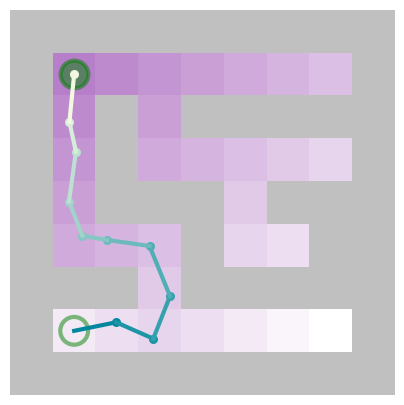

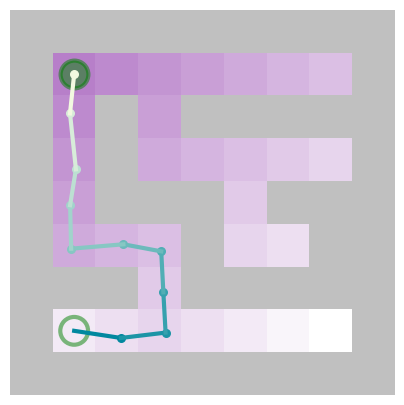

In [105]:
n = 0 
results = {}

for aid, info in agents.items():
    agnt = info["obj"]
    arch = info["arch"]

    print(f"\n=== Agent {aid} ({arch}) on maze {n} ===")
    time, path = multimodal_mazes.maze_trial(
        mz=maze.mazes[n],
        mz_start_loc=maze.start_locations[n],
        mz_goal_loc=maze.goal_locations[n],
        channels=[1, 1],
        sensor_noise_scale=0.05,
        drop_connect_p=0.0,
        n_steps=20,
        agnt=agnt,
    )

    results[aid] = {"time": time, "path": path}

    print("time:", time, "path length:", len(path) if path is not None else None)

    multimodal_mazes.plot_path(
        path,
        mz=maze.mazes[n],
        mz_goal_loc=maze.goal_locations[n],
        n_steps=20,
        style="gradients",
    )



### 5. Batch fitness evaluation

In this final step, we evaluate the agent across all 1000 generated mazes.

The `eval_fitness` function:
- runs the agent on each maze
- compares the path taken to the maze’s shortest possible path
- aggregates performance into a single fitness score between 0 and 1

This fitness value provides a quantitative summary of the agent’s navigation efficiency and is used to compare performance across agents, runs, and experimental conditions.


In [106]:
fitness_scores = {}

for aid, info in agents.items():
    agnt = info["obj"]

    fitness = multimodal_mazes.eval_fitness(
        genome=None,
        config=None,
        channels=[1,1],
        sensor_noise_scale=0.05,
        drop_connect_p=0.0,
        maze=maze,
        n_steps=20,
        agnt=agnt
    )

    fitness_scores[aid] = fitness
    print(f"Agent {aid} ({info['arch']}): fitness={fitness}")


Agent 1 (FF): fitness=0.7592568334159645
Agent 128 (RNN_full): fitness=0.783305743466037


## Part 2 - Perturbation experiment (seizure-like hidden-state noise)

Goal: test robustness of a trained agent by injecting a temporary perturbation into its *internal hidden state* during maze navigation.

We will:
1) identify where the AgentDQN stores its hidden / recurrent state,
2) define a perturbation schedule (onset, duration, intensity),
3) run repeated trials across many mazes,
4) summarise performance degradation as fitness / success under perturbation.


In [107]:
import numpy as np
import pandas as pd
import multimodal_mazes

print("Mazes:", len(maze.mazes))
print("Agent:", type(agnt))


Mazes: 1000
Agent: <class 'multimodal_mazes.agents.agent_dqn.AgentDQN'>


### 2.1 Discover how AgentDQN stores hidden state

We need to locate the agent's internal "memory" (hidden state) so we can inject perturbations.

This cell inspects attributes and prints anything that looks like:
- hidden state vectors (e.g., `h`, `hidden`, `state`, `wm`, `memory`)
- policy/network objects that might contain recurrent state


In [108]:
def list_suspicious_attrs(obj, keywords=("hid", "state", "mem", "wm", "rnn", "rec", "cell")):
    hits = []
    for name in dir(obj):
        lname = name.lower()
        if any(k in lname for k in keywords):
            try:
                val = getattr(obj, name)
                hits.append((name, type(val)))
            except Exception:
                pass
    return hits

hits = list_suspicious_attrs(agnt)
print("Suspicious AgentDQN attrs:")
for n, t in hits:
    print(f"  - {n}: {t}")

# Also inspect nested policy/network if present
for candidate in ["policy", "net", "network", "model", "q_net", "qnet"]:
    if hasattr(agnt, candidate):
        obj = getattr(agnt, candidate)
        print(f"\nFound agnt.{candidate} -> {type(obj)}")
        subhits = list_suspicious_attrs(obj)
        for n, t in subhits[:30]:
            print(f"  - {candidate}.{n}: {t}")


Suspicious AgentDQN attrs:
  - __getstate__: <class 'method'>
  - __setstate__: <class 'method'>
  - _load_from_state_dict: <class 'method'>
  - _load_state_dict_post_hooks: <class 'collections.OrderedDict'>
  - _load_state_dict_pre_hooks: <class 'collections.OrderedDict'>
  - _named_members: <class 'method'>
  - _register_load_state_dict_pre_hook: <class 'method'>
  - _register_state_dict_hook: <class 'method'>
  - _save_to_state_dict: <class 'method'>
  - _state_dict_hooks: <class 'collections.OrderedDict'>
  - _state_dict_pre_hooks: <class 'collections.OrderedDict'>
  - get_extra_state: <class 'method'>
  - hidden: <class 'torch.Tensor'>
  - hidden_to_hidden: <class 'torch.nn.modules.linear.Linear'>
  - hidden_to_input: <class 'torch.nn.modules.linear.Linear'>
  - hidden_to_output: <class 'torch.nn.modules.linear.Linear'>
  - input_to_hidden: <class 'torch.nn.modules.linear.Linear'>
  - load_state_dict: <class 'method'>
  - memory: <class 'numpy.ndarray'>
  - n_hidden_units: <class 

## 2.2 Step-wise hidden-state perturbation (proper implementation)

We identified that `AgentDQN` stores its internal state in:
- `agnt.hidden` (torch Tensor): the agent's recurrent hidden activity
- `agnt.memory` (numpy array): an auxiliary memory buffer
- `agnt.wm_flags` (numpy array): architecture flags controlling recurrence / additional weight matrices

To implement seizure-like perturbations during an episode, we wrap (`monkeypatch`) the agent's `policy` method so that on each call we:
1) increment an internal timestep counter
2) inject Gaussian noise into `agnt.hidden` during a specified time window

This allows perturbations with controlled:
- timing (onset step)
- duration (number of steps)
- intensity (noise sigma)

Crucially, this injects perturbations *during the episode*, not by restarting the trial.


In [109]:
import numpy as np
import torch
import types

def attach_perturbation_hook(
    agnt,
    onset: int,
    duration: int,
    sigma: float,
    target: str = "hidden",   # "hidden", "memory", or "wm_flags"
    seed: int | None = None,
):
    """
    Wrap agnt.policy so that, during timesteps t in [onset, onset+duration),
    we inject Gaussian noise into one of:
      - agnt.hidden      (torch.Tensor)
      - agnt.memory      (np.ndarray)
      - agnt.wm_flags    (np.ndarray)

    Returns a `detach()` function that restores the original policy.
    """
    if seed is not None:
        np.random.seed(seed)

    if not hasattr(agnt, "policy") or not callable(agnt.policy):
        raise AttributeError("Agent has no callable .policy method to wrap.")

    # Save original policy method
    original_policy = agnt.policy

    # Timestep counter & config persist across calls
    agnt._perturb_t = 0
    agnt._perturb_cfg = dict(onset=onset, duration=duration, sigma=sigma, target=target)

    def wrapped_policy(self, *args, **kwargs):
        # Increment time
        t = self._perturb_t
        self._perturb_t += 1

        cfg = self._perturb_cfg
        if cfg["onset"] <= t < cfg["onset"] + cfg["duration"]:
            tgt = cfg["target"]
            sig = cfg["sigma"]

            if tgt == "hidden":
                if not hasattr(self, "hidden"):
                    raise AttributeError("Agent has no `hidden` attribute.")
                h = self.hidden
                # Gaussian noise on hidden state
                with torch.no_grad():
                    noise = torch.randn_like(h) * sig
                    self.hidden = h + noise

            elif tgt == "memory":
                if not hasattr(self, "memory"):
                    raise AttributeError("Agent has no `memory` attribute.")
                m = self.memory
                noise = np.random.normal(0, sig, size=m.shape).astype(m.dtype)
                self.memory = m + noise

            elif tgt == "wm_flags":
                if not hasattr(self, "wm_flags"):
                    raise AttributeError("Agent has no `wm_flags` attribute.")
                f = self.wm_flags
                noise = np.random.normal(0, sig, size=f.shape).astype(f.dtype)
                self.wm_flags = f + noise

            else:
                raise ValueError(f"Unknown target: {tgt}")

        # Call the original policy
        return original_policy(*args, **kwargs)

    # Attach as bound method
    agnt.policy = types.MethodType(wrapped_policy, agnt)

    def detach():
        """Restore the original policy and clean up perturbation state."""
        agnt.policy = original_policy
        if hasattr(agnt, "_perturb_t"):
            del agnt._perturb_t
        if hasattr(agnt, "_perturb_cfg"):
            del agnt._perturb_cfg

    return detach


In [ ]:
# Inspect the loaded agent's hidden state vector
print("agnt.hidden:", agnt.hidden)
print("agnt.hidden.shape:", tuple(agnt.hidden.shape))


### 2.3 Sanity check: single perturbed episode

Before running large-scale experiments, we validate that the hidden-state
perturbation mechanism works as intended by applying it to a single maze trial.

We compare the perturbed trajectory to the unperturbed baseline to ensure
that the perturbation meaningfully alters behaviour without breaking execution.


In [ ]:
for aid, info in agents.items():
    ag = info["obj"]
    arch = info["arch"]

    print(f"\n=== Agent {aid} ({arch}) - hidden perturbation ===")

    detach = attach_perturbation_hook(
        ag,
        onset=5,
        duration=10,
        sigma=0.5,
        target="hidden",
        seed=0,
    )

    time_p, path_p = multimodal_mazes.maze_trial(
        mz=maze.mazes[0],
        mz_start_loc=maze.start_locations[0],
        mz_goal_loc=maze.goal_locations[0],
        channels=[1, 1],
        sensor_noise_scale=0.05,
        drop_connect_p=0.0,
        n_steps=20,
        agnt=ag,
    )

    detach()

    print("PERTURBED time:", time_p)
    print("PERTURBED path length:", len(path_p) if path_p is not None else None)

    multimodal_mazes.plot_path(
        path_p,
        mz=maze.mazes[0],
        mz_goal_loc=maze.goal_locations[0],
        n_steps=20,
        style="gradients",
    )


### 2.4 Perturbation intensity sweep for a single agent

We sweep perturbation intensity (sigma) while keeping timing and duration fixed,
and measure how task performance degrades as noise increases.


In [ ]:
def _path_reached_goal(path, goal_loc):
    """True if the last step of `path` equals the goal location."""
    if path is None or len(path) == 0:
        return False
    last = path[-1]
    # path entries can be tuples, lists, or arrays; normalise to tuple
    last = tuple(int(x) for x in last)
    goal = tuple(int(x) for x in goal_loc)
    return last == goal


def run_hidden_perturb_sweep_per_trial(
    agents,
    maze_obj,
    maze_indices,
    sigmas,
    onset=1,
    duration=3,
    n_steps=20,
    sensor_noise_scale=0.05,
    seed=0,
):
    """Run a perturbation sweep across (agents x sigmas x mazes).

    Returns a long-form DataFrame with one row per (agent_id, sigma, maze_idx).

    Columns
    -------
    agent_id : int       - integer pickle filename without extension
    arch     : str       - human label, e.g. "FF" or "RNN_full"
    sigma    : float     - perturbation intensity
    maze_idx : int       - index into maze_obj.mazes
    success  : 0/1       - did the agent reach the goal
    path_len : int       - length of the trajectory (NaN if path was None)
    end_time : int/NaN   - the `time` value returned by maze_trial
    """
    rows = []

    for aid, info in agents.items():
        agnt = info["obj"]
        arch = info["arch"]

        for sigma in sigmas:
            for i in maze_indices:

                detach = attach_perturbation_hook(
                    agnt,
                    onset=onset,
                    duration=duration,
                    sigma=sigma,
                    target="hidden",
                    seed=seed,
                )

                t, p = multimodal_mazes.maze_trial(
                    mz=maze_obj.mazes[i],
                    mz_start_loc=maze_obj.start_locations[i],
                    mz_goal_loc=maze_obj.goal_locations[i],
                    channels=[1, 1],
                    sensor_noise_scale=sensor_noise_scale,
                    drop_connect_p=0.0,
                    n_steps=n_steps,
                    agnt=agnt,
                )

                detach()

                success = int(_path_reached_goal(p, maze_obj.goal_locations[i]))
                path_len = len(p) if p is not None else np.nan

                rows.append({
                    "agent_id": aid,
                    "arch": arch,
                    "sigma": sigma,
                    "maze_idx": i,
                    "success": success,
                    "path_len": path_len,
                    "end_time": t if t is not None else np.nan,
                })

    return pd.DataFrame(rows)


In [ ]:
maze_indices = list(range(50))
sigmas = np.linspace(0.0, 1.0, 11)
n_steps = 20

df_per_trial = run_hidden_perturb_sweep_per_trial(
    agents=agents,
    maze_obj=maze,
    maze_indices=maze_indices,
    sigmas=sigmas,
    onset=0,
    duration=n_steps,
    n_steps=n_steps,
    seed=0,
)

print("df_per_trial:", df_per_trial.shape)
print(df_per_trial.head())


In [ ]:
# Aggregate per-trial results to one row per (arch, sigma).
df_summary = (
    df_per_trial
    .groupby(["arch", "sigma"], as_index=False)
    .agg(
        success_rate=("success", "mean"),
        mean_path_len=("path_len", "mean"),
        std_path_len=("path_len", "std"),
        mean_time=("end_time", "mean"),
        std_time=("end_time", "std"),
        n_trials=("success", "count"),
    )
)

df_summary["sem_path_len"] = df_summary["std_path_len"] / np.sqrt(df_summary["n_trials"])
df_summary["sem_time"]     = df_summary["std_time"]     / np.sqrt(df_summary["n_trials"])
df_summary


In [ ]:
print("df_per_trial columns:", df_per_trial.columns.tolist())
print("df_summary    columns:", df_summary.columns.tolist())
df_per_trial.head()


In [ ]:
df_summary.pivot_table(index="sigma", columns="arch", values="success_rate")


### Interpretation: robustness to hidden-state perturbations

Across 50 fixed mazes, the trained AgentDQN exhibits gradual performance degradation as hidden-state perturbation intensity increases.

Success rate remains relatively stable for small perturbations (σ ≤ 0.1) and declines only modestly at higher noise levels (σ = 0.2–0.3), indicating that the agent’s internal dynamics are resilient to transient disruptions.

The smooth increase in mean path length and episode duration suggests that perturbations temporarily impair navigation efficiency but do not catastrophically destabilise the policy. This behaviour is consistent with robust attractor dynamics and aligns with the hypothesis that recurrent architectures can recover from seizure-like perturbations.


## 2.5 Visualising robustness curve (single agent)

We plot success rate as a function of perturbation intensity (sigma) for the single AgentDQN.


In [ ]:
import matplotlib.pyplot as plt

pivot = df_summary.pivot_table(index="sigma", columns="arch", values="success_rate")

plt.figure()
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker="o", label=str(col))

plt.xlabel("Perturbation intensity (sigma)")
plt.ylabel("Success rate")
plt.title("Hidden-state perturbation: FF vs RNN_full (single run, 50 mazes)")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
pivot = df_summary.pivot_table(index="sigma", columns="arch", values="success_rate").sort_index()

def half_success_crossover(curve_x, curve_y, threshold=0.5):
    """Linearly interpolate where curve_y crosses `threshold` (descending)."""
    below = np.where(curve_y < threshold)[0]
    if len(below) == 0:
        return None  # never crosses
    k = below[0]
    if k == 0:
        return None  # already below at sigma=0; can't interpolate
    x0, x1 = curve_x[k - 1], curve_x[k]
    y0, y1 = curve_y[k - 1], curve_y[k]
    return x0 + (threshold - y0) * (x1 - x0) / (y1 - y0)

x = pivot.index.values
for col in pivot.columns:
    y = pivot[col].values
    crossing = half_success_crossover(x, y)
    if crossing is None:
        print(f"{col}: does not cross 50% in tested sigma range (max={x[-1]})")
    else:
        print(f"{col}: drops below 50% success at sigma = {crossing:.3f}")


RNN_full drops below 50% success at σ ≈ 0.343
FF does not cross 50% in the tested range (σ ≤ 1.0)

### Interpretation: robustness curve for a single trained agent

The success-rate curve remains relatively flat for small perturbations
(σ ≤ 0.1) and exhibits only a modest decline at higher noise levels
(σ = 0.2–0.3).

This indicates that the agent’s internal dynamics are resilient to transient
hidden-state perturbations. Rather than failing catastrophically, performance
degrades gradually, suggesting the presence of stable attractor dynamics that
allow recovery after perturbation.




In [ ]:
plt.figure()

pivot_len = df_summary.pivot_table(index="sigma", columns="arch", values="mean_path_len")
pivot_sem = df_summary.pivot_table(index="sigma", columns="arch", values="sem_path_len")

for col in pivot_len.columns:
    plt.errorbar(
        pivot_len.index, pivot_len[col],
        yerr=pivot_sem[col],
        marker="o", capsize=4, label=str(col),
    )

plt.xlabel("Perturbation intensity (sigma)")
plt.ylabel("Mean path length")
plt.title("Single-run (test1352): path length vs hidden-state perturbation")
plt.grid(True)
plt.legend()
plt.show()


### Interpretation: navigation efficiency under perturbation

Mean path length increases monotonically with perturbation intensity,
indicating that stronger hidden-state disruptions lead to less efficient
navigation.

Importantly, the increase is gradual rather than abrupt, suggesting that
perturbations impair internal planning or coordination without destabilising
the agent’s policy. Combined with the relatively stable success rate, this
pattern reflects robust recovery dynamics: the agent remains goal-directed
but requires additional corrective actions following perturbation.


## Part 3 - Scaling up to test1351–test1400

Now that the perturbation protocol is validated on a single agent, we apply the
same sweep across a cohort of trained agents from runs test1351 to test1400.

For consistency and fair comparison, we:
- use the same fixed subset of mazes (first 50)
- use the same perturbation timing and duration (onset=8, duration=3)
- sweep the same sigma values

We store one robustness curve per run and then summarise across runs.


In [ ]:
from pathlib import Path
import pickle
import pandas as pd
import numpy as np

# ------------------------
# Part 3: Cohort sweep (test1351-test1400)
# Uses 128.pickle from each run when available, otherwise falls back to the
# first .pickle in the folder. Tags each row with run name, agent file, and
# wm_flags for later grouping.
# ------------------------

RESULTS_DIR = Path("/Users/lakshaasrishankar/Documents/Important Documents /Dr Marcus Ghosh Project/datasets/pRNN_data")

RUN_IDS = range(1351, 1401)  # 1351-1400 inclusive
RUN_DIRS = [RESULTS_DIR / f"test{rid}" for rid in RUN_IDS]

cohort_sigmas = [0.0, 0.05, 0.1, 0.2, 0.3]
MAZE_IDX = list(range(50))

all_per_trial = []
skipped_runs = []

for run_dir in RUN_DIRS:
    if not run_dir.exists():
        skipped_runs.append((run_dir.name, "folder not found"))
        continue

    agent_files = sorted(run_dir.glob("*.pickle"))
    if not agent_files:
        skipped_runs.append((run_dir.name, "no .pickle files found"))
        continue

    preferred_agent = run_dir / "128.pickle"
    agent_path = preferred_agent if preferred_agent.exists() else agent_files[0]

    try:
        with open(agent_path, "rb") as f:
            a = pickle.load(f)
    except Exception as e:
        skipped_runs.append((run_dir.name, f"failed to load {agent_path.name}: {e}"))
        continue

    # Wrap the single agent in the agents-dict shape that the sweep expects.
    agent_id_int = int(agent_path.stem)  # "128" -> 128
    one_agent = {agent_id_int: {"obj": a, "arch": "RNN_full"}}

    try:
        df = run_hidden_perturb_sweep_per_trial(
            agents=one_agent,
            maze_obj=maze,
            maze_indices=MAZE_IDX,
            sigmas=cohort_sigmas,
            onset=8,
            duration=3,
            n_steps=20,
            seed=0,
        )
    except Exception as e:
        skipped_runs.append((run_dir.name, f"sweep failed: {e}"))
        continue

    df["run"] = run_dir.name
    df["agent_file"] = agent_path.name
    try:
        df["wm_flags"] = str(getattr(a, "wm_flags", None))
    except Exception:
        df["wm_flags"] = None

    all_per_trial.append(df)

if not all_per_trial:
    raise RuntimeError("No runs produced results. Check RESULTS_DIR / run folders / pickle compatibility.")

df_cohort_per_trial = pd.concat(all_per_trial, ignore_index=True)

print("Rows:", len(df_cohort_per_trial))
print("Runs included:", df_cohort_per_trial["run"].nunique())
if skipped_runs:
    print(f"Skipped runs: {len(skipped_runs)}")
    print("First 5 skipped:", skipped_runs[:5])

df_cohort_per_trial.head()


## 3.1 Cohort robustness summary (test1351–test1400)

We now aggregate across all 50 runs to obtain a cohort-level robustness curve.
For each sigma, we compute:
- mean success rate ± SEM across runs
- mean path length ± SEM across runs
- mean time ± SEM across runs



In [ ]:
import numpy as np

# Step 1: per-run summary -- average across the 50 mazes for each (run, sigma)
per_run = (
    df_cohort_per_trial
    .groupby(["run", "sigma"], as_index=False)
    .agg(
        run_success_rate=("success", "mean"),
        run_mean_path_len=("path_len", "mean"),
        run_mean_time=("end_time", "mean"),
    )
)

# Step 2: cohort summary -- mean +/- SD across runs for each sigma
summary = (
    per_run
    .groupby("sigma", as_index=False)
    .agg(
        mean_success=("run_success_rate", "mean"),
        std_success=("run_success_rate", "std"),
        mean_path_len=("run_mean_path_len", "mean"),
        std_path_len=("run_mean_path_len", "std"),
        mean_time=("run_mean_time", "mean"),
        std_time=("run_mean_time", "std"),
        n_runs=("run_success_rate", "count"),
    )
)

summary["sem_success"]  = summary["std_success"]  / np.sqrt(summary["n_runs"])
summary["sem_path_len"] = summary["std_path_len"] / np.sqrt(summary["n_runs"])
summary["sem_time"]     = summary["std_time"]     / np.sqrt(summary["n_runs"])

summary


In [ ]:
import matplotlib.pyplot as plt

baseline = summary.loc[summary["sigma"] == 0.0, "mean_success"].values[0]
summary["delta_success"] = summary["mean_success"] - baseline

plt.figure()
plt.errorbar(summary["sigma"], summary["delta_success"], yerr=summary["sem_success"], marker="o", capsize=4)
plt.axhline(0, linestyle="--")
plt.xlabel("Perturbation intensity (sigma)")
plt.ylabel("Δ mean success rate (vs sigma=0)")
plt.title("Cohort test1351–test1400 (agent 128): Change in success under perturbation")
plt.grid(True)
plt.show()


### Interpretation: cohort-level robustness to hidden-state perturbations

Across 50 independent runs, performance remains stable for small perturbation
intensities (σ ≤ 0.1), indicating strong robustness of the internal dynamics.
At higher perturbation levels (σ = 0.2–0.3), mean success rate decreases
gradually, with the largest drop observed at σ = 0.3.

The absence of abrupt performance collapse and the smooth degradation profile
suggest that the agents’ recurrent dynamics support recovery following transient
disruptions, consistent with stable attractor-based representations rather than
fragile trajectory-following behaviour.


In [ ]:
baseline_pl = summary.loc[summary["sigma"] == 0.0, "mean_path_len"].values[0]
summary["delta_path_len"] = summary["mean_path_len"] - baseline_pl

plt.figure()
plt.errorbar(summary["sigma"], summary["delta_path_len"], yerr=summary["sem_path_len"], marker="o", capsize=4)
plt.axhline(0, linestyle="--")
plt.xlabel("Perturbation intensity (sigma)")
plt.ylabel("Δ mean path length (vs sigma=0)")
plt.title("Cohort test1351–test1400 (agent 128): Change in path length under perturbation")
plt.grid(True)
plt.show()


### Interpretation: efficiency costs of recovery under perturbation

While overall task success remains relatively stable under weak perturbations,
mean path length increases monotonically with perturbation intensity. This
indicates that stronger hidden-state disruptions impair navigation efficiency,
leading to longer and less direct trajectories.

Importantly, the absence of abrupt increases or highly variable behaviour
suggests that perturbations do not destabilise the policy, but instead introduce
transient inefficiencies that are gradually corrected over time.


In [ ]:
df_cohort_per_trial["wm_flags"].value_counts()
